In [95]:
import duckdb
import pandas as pd
import os
import json
from dotenv import load_dotenv

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, f1_score, confusion_matrix

from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")

# --- CONFIGURAÇÕES GLOBAIS DE AMBIENTE E FILTROS ---
load_dotenv()
data_inicio = os.getenv("DATA_INICIO")
data_fim = os.getenv("DATA_FIM")
curso_id = os.getenv("CURSO_ID")

limites_str = os.getenv('LIMITES_NOTAS', '-0.01,0.2,0.4,0.6,0.8,1.0')
rotulos_str = os.getenv('ROTULOS_NOTAS', '1_Muito_Ruim,2_Ruim,3_Regular,4_Bom,5_Muito_Bom')

limites = [float(x.strip()) for x in limites_str.split(',')]
rotulos = [x.strip() for x in rotulos_str.split(',')]

usuarios_ignorados = "('0', '-1', '', 'nan', 'user6442803380426375169', 'user8540069828419911681')" 
filtro_curso_periodo = (
    f"(courseid = '{curso_id}' OR courseid = '0') AND "
    f"CAST(timecreated AS BIGINT) BETWEEN "
    f"epoch(TIMESTAMP '{data_inicio} 00:00:00') AND "
    f"epoch(TIMESTAMP '{data_fim} 23:59:59')"
)


In [96]:
def extrair_features_moodle(pasta_dados="export/", curso_id="10464"):
    """
    Varre os logs brutos do Moodle e consolida métricas comportamentais 
    por aluno usando processamento analítico do DuckDB.
    """
    
    query_features = f"""
        SELECT 
            username,
            -- 1. Features de Volume de Engajamento
            COUNT(*) AS total_cliques,
            
            -- Converte o timestamp Unix para Data e conta os dias distintos estudados
            COUNT(DISTINCT CAST(to_timestamp(CAST(timecreated AS BIGINT)) AS DATE)) AS dias_ativos,
            
            -- 2. Features Comportamentais (Ativo vs Passivo)
            SUM(CASE WHEN crud IN ('c', 'u') THEN 1 ELSE 0 END) AS interacoes_ativas,
            SUM(CASE WHEN crud = 'r' THEN 1 ELSE 0 END) AS interacoes_passivas,
            
            -- 3. Features de Foco em Componentes
            SUM(CASE WHEN component = 'mod_forum' THEN 1 ELSE 0 END) AS cliques_forum,
            SUM(CASE WHEN component = 'mod_quiz' THEN 1 ELSE 0 END) AS cliques_quiz,
            SUM(CASE WHEN component IN ('mod_resource', 'mod_book', 'mod_page') THEN 1 ELSE 0 END) AS cliques_materiais
            
        FROM read_csv_auto('{pasta_dados}limpo_mdl_logstore_standard_log.csv', ALL_VARCHAR=TRUE)
        WHERE username NOT IN {usuarios_ignorados} 
          AND username IS NOT NULL
          AND {filtro_curso_periodo}
        GROUP BY username
        ORDER BY total_cliques DESC
    """
    
    # Executa a query e já devolve um DataFrame Pandas limpinho
    df_features = duckdb.query(query_features).df()
    return df_features

df = extrair_features_moodle()
print(df.head())

     username  total_cliques  dias_ativos  interacoes_ativas  \
0  aluno_2167          94124           30            69684.0   
1  aluno_2168          79744           27            76488.0   
2    aluno_24          31421           30            18798.0   
3   aluno_312          10741           29             8703.0   
4   aluno_333           9285           28             3294.0   

   interacoes_passivas  cliques_forum  cliques_quiz  cliques_materiais  
0              24326.0        16808.0         266.0              776.0  
1               3248.0         1056.0          10.0              100.0  
2              12587.0        13073.0          33.0              178.0  
3               2007.0          602.0          67.0              242.0  
4               5983.0         4585.0          37.0               77.0  


In [97]:
def extrair_notas_medias_1(pasta_dados="export/"):                                                                                                         
    """                                                                                                                                                  
    Extrai a nota mais recente de cada item para cada aluno                                                                                              
    e calcula a nota média final (Target),                                                                                                               
    filtrando o período de tempo definido pelas variáveis globais.                                                                                       
    """                                                                                                                                                  
    query_notas = f"""                                                                                                                                   
        WITH TotalItens AS (                                                                                                                             
            SELECT COUNT(DISTINCT itemid) AS total_atividades                                                                                            
            FROM read_csv_auto('{pasta_dados}limpo_mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)                                                            
            WHERE finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL                                                                       
                AND CAST(timemodified AS BIGINT) BETWEEN epoch(TIMESTAMP '{data_inicio} 00:00:00') AND epoch(TIMESTAMP '{data_fim} 23:59:59')              
        ),                                                                                                                                               
        NotasRecentes AS (                                                                                                                               
            SELECT                                                                                                                                       
                username,                                                                                                                                
                itemid,                                                                                                                                  
                arg_max(CAST(finalgrade AS FLOAT), CAST(timemodified AS BIGINT)) AS nota_recente,                                                        
                arg_max(CAST(rawgrademax AS FLOAT), CAST(timemodified AS BIGINT)) AS nota_maxima                                                         
            FROM read_csv_auto('{pasta_dados}limpo_mdl_grade_grades_history.csv', ALL_VARCHAR=TRUE)                                                            
            WHERE finalgrade NOT IN ('', 'nan', 'None') AND finalgrade IS NOT NULL                                                                       
                AND rawgrademax NOT IN ('', 'nan', 'None') AND rawgrademax IS NOT NULL                                                                     
                AND username NOT IN {usuarios_ignorados}                                                                                                   
                AND CAST(timemodified AS BIGINT) BETWEEN epoch(TIMESTAMP '{data_inicio} 00:00:00') AND epoch(TIMESTAMP '{data_fim} 23:59:59')              
            GROUP BY username, itemid                                                                                                                    
        ),                                                                                                                                               
        NotasNormalizadas AS (                                                                                                                           
            -- Calcular a proporção (0 a 1) para cada atividade                                                                                          
            SELECT                                                                                                                                       
                username,                                                                                                                                
                itemid,                                                                                                                                  
                CASE                                                                                                                                     
                    WHEN nota_maxima > 0 THEN nota_recente / nota_maxima                                                                                 
                    ELSE 0.0                                                                                                                             
                END AS nota_item_0_a_1                                                                                                                   
            FROM NotasRecentes                                                                                                                           
        )                                                                                                                                                
        -- Calcular a média geral final do aluno                                                                                                         
        SELECT                                                                                                                                           
            username,                                                                                                                                    
            SUM(nota_item_0_a_1) / (SELECT total_atividades FROM TotalItens) AS nota_media                                                               
        FROM NotasNormalizadas                                                                                                                           
        GROUP BY username                                                                                                                                
        ORDER BY nota_media DESC                                                                                                                         
    """                                                                                                                                                  
                                                                                                                                                            
    # Executa a query e retorna o DataFrame                                                                                                              
    return duckdb.query(query_notas).df()                                                                                                                
                                                    
def extrair_notas_medias_2(arquivo_json="export/pontuacao.json"):
    print("🎯 Extraindo Target Oficial via JSON (apenas alunos com nota)...")
    
    try:
        # Carrega os dados do JSON
        df_json = pd.read_json(arquivo_json)
        
        # Renomeia a coluna para o padrão do nosso pipeline (chave do merge)
        df_json = df_json.rename(columns={'usuario': 'username'})
        
        # Cria a métrica normalizada de 0 a 1 (dividindo por 10)
        # O clip(0, 1) protege contra eventuais pontuações anômalas
        df_json['nota_media'] = (df_json['pontuacao'] / 10.0).clip(0, 1)
        
        # Separa apenas as colunas que importam para o ML
        df_alvo = df_json[['username', 'nota_media']].copy()
        
        # Ordena do maior para o menor para facilitar a visualização
        df_alvo = df_alvo.sort_values(by='nota_media', ascending=False).reset_index(drop=True)
        
        print(f"✅ Target gerado com sucesso! Total de alunos avaliados no JSON: {len(df_alvo)}")
        return df_alvo
        
    except FileNotFoundError:
        print(f"❌ Erro: O arquivo {arquivo_json} não foi encontrado. Verifique o caminho.")
        return None                                                                                                            
                                                    
# Executa a função e guarda o DataFrame com o nosso "Target"
df_target = extrair_notas_medias_2()

# Exibe as primeiras linhas para validação
print(df_target.shape[0], " alunos no target")
df_target.head(20)

🎯 Extraindo Target Oficial via JSON (apenas alunos com nota)...
✅ Target gerado com sucesso! Total de alunos avaliados no JSON: 1177
1177  alunos no target


,username,nota_media
0,aluno_137,1.0
1,aluno_424,1.0
2,aluno_54,1.0
3,aluno_1475,1.0
4,aluno_385,1.0
5,aluno_1168,1.0
6,aluno_292,1.0
7,aluno_315,1.0
8,aluno_377,1.0
9,aluno_1061,1.0


In [98]:
from functools import reduce

# 1. Configuração

load_dotenv()

export_path = os.getenv("PASTA_DADOS")

atividades_path = os.path.join(export_path, "atividades.json")
nivel_desordem_path = os.path.join(export_path, "nivel_desordem.json")
visualizacoes_por_objeto_path = os.path.join(export_path, "visualizacoes_por_objeto.json")
proporcao_visualizacoes_path = os.path.join(export_path, "proporcao_visualizacoes_por_atividade.json")
pontuacao_path = os.path.join(export_path, "pontuacao.json")
porcentagem_curso_path = os.path.join(export_path, "porcentagem_curso_acessada.json")
tentativas_por_questionario_path = os.path.join(export_path, "tentativas_por_questionario.json")
tempo_resposta_path = os.path.join(export_path, "tempo_resposta.json")
tempo_total_gasto_path = os.path.join(export_path, "tempo_total_gasto_em_visitas_reais.json")

# 2.1. Desordem por Sessão

with open(nivel_desordem_path, 'r', encoding='utf-8') as f:
    desordem_json = json.load(f)
dados_desordem = {}
for id_sessao, dados_sessao in desordem_json.get("Course 10464", {}).get("sessoes", {}).items():
    for username, valor in dados_sessao.get("nivel_desordem_por_usuario", {}).items():
        if username not in dados_desordem:
            dados_desordem[username] = {"username": username}
        dados_desordem[username][f"desordem_sessao_{id_sessao}"] = valor
df_desordem = pd.DataFrame(list(dados_desordem.values()))

# 2.2. Pontuação
with open(pontuacao_path, 'r', encoding='utf-8') as f:
    pont_data = json.load(f)
df_pontuacao = pd.DataFrame(pont_data)[['usuario', 'pontuacao']]
df_pontuacao = df_pontuacao.rename(columns={'usuario': 'username'}) # Padronizando a chave

# 2.3. Porcentagem do Curso Acessada (Desdobrando geral e sessões)
with open(porcentagem_curso_path, 'r', encoding='utf-8') as f:
    perc_json = json.load(f)
dados_perc = []
for username, dados_aluno in perc_json.get('Course 10464', {}).items():
    registro = {'username': username, 'porcentagem_geral': dados_aluno.get('geral', 0.0)}
    for id_sessao, valor_sessao in dados_aluno.get('sessoes', {}).items():
        registro[f'porcentagem_sessao_{id_sessao}'] = valor_sessao
    dados_perc.append(registro)
df_porcentagem = pd.DataFrame(dados_perc)

# 2.4. Tentativas por Questionário (Somando tudo por aluno)
with open(tentativas_por_questionario_path, 'r', encoding='utf-8') as f:
    tentativas_data = json.load(f)
df_tentativas = pd.DataFrame(tentativas_data)
df_tentativas = df_tentativas.groupby('usuario')['total_tentativas'].sum().reset_index()
df_tentativas = df_tentativas.rename(columns={'usuario': 'username', 'total_tentativas': 'soma_tentativas_quizzes'})

# 2.5. Tempo de Resposta (Transformando PT...S em segundos)
with open(tempo_resposta_path, 'r', encoding='utf-8') as f:
    tempo_resp_data = json.load(f)
df_tempo_resp = pd.DataFrame(tempo_resp_data)

# Regex para extrair D, H, M, S de um formato ISO 8601
regex_tempo = r'P(?:(\d+)D)?T(?:(\d+)H)?(?:(\d+)M)?(?:(\d+)S)?'
extraido_resp = df_tempo_resp['tempo_resposta'].str.extract(regex_tempo).fillna(0).astype(int)

# D*86400 + H*3600 + M*60 + S
df_tempo_resp['tempo_resp_segundos'] = (
    extraido_resp[0] * 86400 + 
    extraido_resp[1] * 3600 + 
    extraido_resp[2] * 60 + 
    extraido_resp[3]
)

# Tirando a média de tempo de resposta por aluno
df_tempo_resp = df_tempo_resp.groupby('usuario')['tempo_resp_segundos'].mean().reset_index()
df_tempo_resp = df_tempo_resp.rename(columns={'usuario': 'username', 'tempo_resp_segundos': 'media_tempo_resposta_seg'})


# ==========================================
# 2.6. Tempo Total Gasto na Plataforma
# ==========================================
with open(tempo_total_gasto_path, 'r', encoding='utf-8') as f:
    tempo_gasto_data = json.load(f)
df_tempo_gasto = pd.DataFrame(tempo_gasto_data)

# Aplicando a mesma extração Regex (O Moodle pode gerar números enormes como PT436985S aqui)
extraido_gasto = df_tempo_gasto['tempo_passado'].str.extract(regex_tempo).fillna(0).astype(int)

# Calculando Segundos
df_tempo_gasto['tempo_passado_seg'] = (
    extraido_gasto[0] * 86400 + 
    extraido_gasto[1] * 3600 + 
    extraido_gasto[2] * 60 + 
    extraido_gasto[3]
)

# Somando todo o tempo das visitas do aluno
df_tempo_gasto = df_tempo_gasto.groupby('usuario')['tempo_passado_seg'].sum().reset_index()
df_tempo_gasto = df_tempo_gasto.rename(columns={'usuario': 'username', 'tempo_passado_seg': 'tempo_total_ambiente_seg'})

# 2.7. Feedback Lido por Usuário

with open(os.path.join(export_path, "feedback_lido_por_usuario.json"), 'r', encoding='utf-8') as f:
    feedback_data = json.load(f)

dados_feedback = {}

# Navega pelas sessões dentro do curso
for id_sessao, dados_sessao in feedback_data.get("Course 10464", {}).get("sessoes", {}).items():
    
    # Navega pelos usuários dentro da chave "usuarios" de cada sessão
    for username, metricas in dados_sessao.get("usuarios", {}).items():
        
        # Se o usuário ainda não existe no dicionário, cria a chave dele
        if username not in dados_feedback:
            dados_feedback[username] = {'username': username}
        
        # Cria as novas features (colunas) com o ID da sessão específico anexado ao nome
        dados_feedback[username][f'feedbacks_dispon_sessao_{id_sessao}'] = metricas.get('feedbacks_disponiveis', 0)
        dados_feedback[username][f'feedbacks_lidos_sessao_{id_sessao}'] = metricas.get('feedbacks_lidos', 0)
        dados_feedback[username][f'porcentagem_fb_lido_sessao_{id_sessao}'] = metricas.get('fr_porcentagem_lida', 0.0)

# Converte o dicionário consolidado para um DataFrame do Pandas
df_feedback = pd.DataFrame(list(dados_feedback.values()))

# ==========================================
# 3. O GRANDE MERGE (Unindo tudo pelo Username)
# ==========================================
# Colocamos todos os DataFrames em uma lista
dataframes_para_unir = [
    df_desordem,
    df_porcentagem, 
    df_tentativas, 
    df_tempo_resp, 
    df_tempo_gasto,
    df_feedback
]

df_final = reduce(lambda left, right: pd.merge(left, right, on='username', how='outer'), dataframes_para_unir)

print(f"✅ Matriz de features construída com sucesso! Total de alunos: {len(df_final)}")
print(f"📊 Total de features (colunas) geradas: {len(df_final.columns)}")
print(f" Total de nulls por coluna:\n{df_final.isnull().sum()}")

df_final.to_csv(os.path.join(export_path, "matriz_comportamental.csv"), index=False)

✅ Matriz de features construída com sucesso! Total de alunos: 2059
📊 Total de features (colunas) geradas: 28
 Total de nulls por coluna:
username                               0
desordem_sessao_58964                277
desordem_sessao_58965                126
desordem_sessao_58966                874
desordem_sessao_58968                979
desordem_sessao_58967               1125
porcentagem_geral                     42
porcentagem_sessao_58964              42
porcentagem_sessao_58965              42
porcentagem_sessao_58969              42
porcentagem_sessao_58966              42
porcentagem_sessao_58968              42
porcentagem_sessao_58967              42
soma_tentativas_quizzes              899
media_tempo_resposta_seg             728
tempo_total_ambiente_seg              14
feedbacks_dispon_sessao_58965        891
feedbacks_lidos_sessao_58965         891
porcentagem_fb_lido_sessao_58965     891
feedbacks_dispon_sessao_58966       1213
feedbacks_lidos_sessao_58966        1213
po

In [99]:
def aplicar_imputacao_simples(X, estrategia='median', valor_constante=0.0):
    print(f"Aplicando imputação: {estrategia}...")

    if estrategia == 'constant':
        imputer = SimpleImputer(
            strategy=estrategia,
            fill_value=valor_constante
        )
    else:
        imputer = SimpleImputer(strategy=estrategia)

    X_imputado = pd.DataFrame(
        imputer.fit_transform(X),
        columns=X.columns,
        index=X.index
    )

    return X_imputado, imputer

In [100]:
def transformar_com_imputador(X, imputer):
    X_imputado = pd.DataFrame(
        imputer.transform(X),
        columns=X.columns,
        index=X.index
    )

    return X_imputado

In [101]:
def treinar_e_avaliar_rf(X_train, X_test, y_train, y_test):
    """Treina Random Forest e retorna métricas de classificação."""
    modelo_rf = RandomForestClassifier(
        n_estimators=200, 
        max_depth=15,
        random_state=42, 
        min_samples_leaf=2,
        class_weight='balanced'
    )
    modelo_rf.fit(X_train, y_train)
    predicoes = modelo_rf.predict(X_test)
    
    acc = accuracy_score(y_test, predicoes)
    prec = precision_score(y_test, predicoes, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predicoes, average='weighted', zero_division=0)
    
    return modelo_rf, acc, prec, f1, predicoes

def treinar_e_avaliar_svm(X_train, X_test, y_train, y_test):
    """Treina SVM com Escalonamento embutido."""

    modelo_svm = make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', C=1.0, random_state=42, class_weight='balanced')
    )
    modelo_svm.fit(X_train, y_train)
    predicoes = modelo_svm.predict(X_test)
    
    acc = accuracy_score(y_test, predicoes)
    prec = precision_score(y_test, predicoes, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predicoes, average='weighted', zero_division=0)
    
    return modelo_svm, acc, prec, f1, predicoes

🔄 Juntando matriz de features com o Target...

Distribuição dos alunos por categoria de desempenho:
classe_desempenho
1_Muito_Ruim    895
2_Ruim           17
3_Regular        65
4_Bom           256
5_Muito_Bom     826
Name: count, dtype: int64

🚀 Iniciando Treinamentos...
----------------------------------------
Testando imputação: MEAN...
Aplicando imputação: mean...
Testando imputação: MEDIAN...
Aplicando imputação: median...
Testando imputação: MOST_FREQUENT...
Aplicando imputação: most_frequent...
Testando imputação: CONSTANT...
Aplicando imputação: constant...

🏆 RANKING DE DESEMPENHO (Ordenado por F1-Score):


,Modelo,Imputacao,Acuracia,Precisao,F1-Score
6,Random Forest,constant,0.810680,0.787717,0.794305
2,Random Forest,median,0.791262,0.767859,0.774461
4,Random Forest,most_frequent,0.788835,0.764103,0.772099
0,Random Forest,mean,0.786408,0.760084,0.768645
7,SVM,constant,0.711165,0.760515,0.729392
1,SVM,mean,0.703883,0.747821,0.722919
3,SVM,median,0.706311,0.743525,0.722512
5,SVM,most_frequent,0.701456,0.749938,0.719926


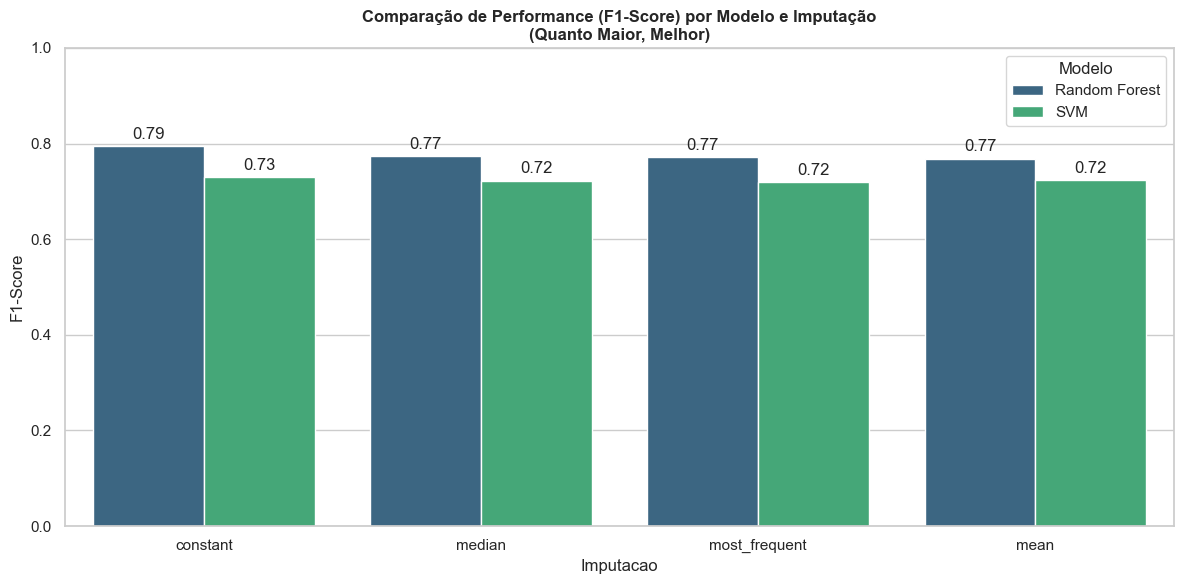


📊 Gerando Matriz de Confusão para a melhor configuração: Random Forest (constant)


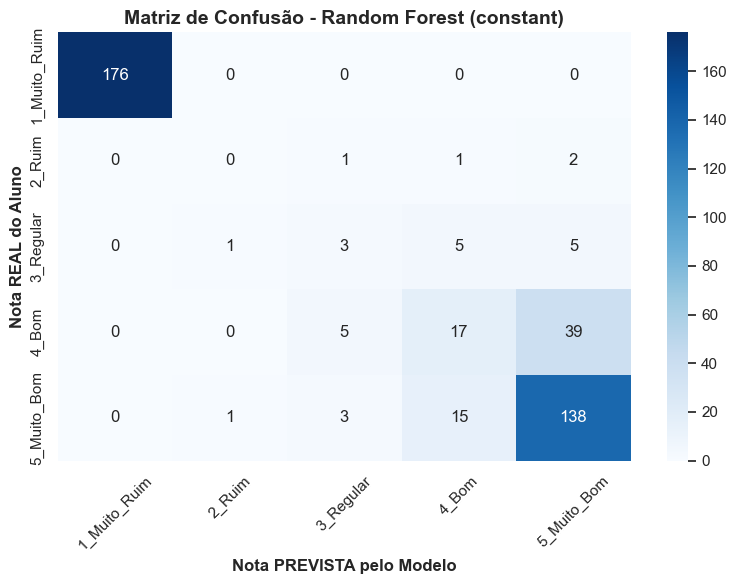

In [102]:
def executar_experimentos_classificacao(df_features, df_alvo, coluna_alvo='nota_media', random_state=42):
    print("🔄 Juntando matriz de features com o Target...")
    df_completo = pd.merge(df_features, df_alvo, on='username', how='left')

    #COM os alunos sme nota media
    df_completo[coluna_alvo] = df_completo[coluna_alvo].fillna(0.0)
    
    df_completo['classe_desempenho'] = pd.cut(df_completo[coluna_alvo], bins=limites, labels=rotulos)
    
    df_completo = df_completo.dropna(subset=['classe_desempenho'])
    
    print("\nDistribuição dos alunos por categoria de desempenho:")
    print(df_completo['classe_desempenho'].value_counts().sort_index())
    
    X = df_completo.drop(columns=['username', coluna_alvo, 'classe_desempenho'])
    y = df_completo['classe_desempenho']
    
    estrategias = ['mean', 'median', 'most_frequent', 'constant']
    resultados = []
    
    # Variáveis para rastrear o melhor modelo para a Matriz de Confusão
    melhor_modelo_final = None
    melhor_X = None
    melhor_f1 = 0
    melhor_config = ""
    melhores_predicoes = None
    y_test_final = None
    
    print("\n🚀 Iniciando Treinamentos...\n" + "-"*40)
    

    for est in estrategias:
        print(f"Testando imputação: {est.upper()}...")
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)
        

        colunas_tempo = [col for col in X_train.columns if 'tempo' in col]
        for col in colunas_tempo:
            limite_superior = X_train[col].quantile(0.95)
            
            X_train[col] = np.where(X_train[col] > limite_superior, limite_superior, X_train[col])
            X_test[col] = np.where(X_test[col] > limite_superior, limite_superior, X_test[col])
            
        X_train, imputer = aplicar_imputacao_simples(
            X_train,
            estrategia=est,
            valor_constante=0.0
        )

        X_test = transformar_com_imputador(
            X_test,
            imputer
        )
        
        # --- Treino Random Forest ---
        modelo_rf, acc_rf, prec_rf, f1_rf, preds_rf = treinar_e_avaliar_rf(X_train, X_test, y_train, y_test)
        resultados.append({'Modelo': 'Random Forest', 'Imputacao': est, 'Acuracia': acc_rf, 'Precisao': prec_rf, 'F1-Score': f1_rf})
        
        if f1_rf > melhor_f1:
            melhor_f1 = f1_rf; melhores_predicoes = preds_rf; y_test_final = y_test
            melhor_config = f"Random Forest ({est})"
            melhor_modelo_final = modelo_rf
            melhor_X = X_train
            

        # --- Treino SVM ---
        modelo_svm, acc_svm, prec_svm, f1_svm, preds_svm = treinar_e_avaliar_svm(X_train, X_test, y_train, y_test)
        resultados.append({'Modelo': 'SVM', 'Imputacao': est, 'Acuracia': acc_svm, 'Precisao': prec_svm, 'F1-Score': f1_svm})
        
        if f1_svm > melhor_f1:
            melhor_f1 = f1_svm; melhores_predicoes = preds_svm; y_test_final = y_test
            melhor_config = f"SVM ({est})"
            melhor_modelo_final = modelo_svm
            melhor_X = X_train


    # 4. EXIBIÇÃO DE RESULTADOS GERAIS
    df_resultados = pd.DataFrame(resultados).sort_values(by='F1-Score', ascending=False)
    print("\n🏆 RANKING DE DESEMPENHO (Ordenado por F1-Score):")
    display(df_resultados)
    
    # 5. GRÁFICO COMPARATIVO DE ESTRATÉGIAS
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=df_resultados, x='Imputacao', y='F1-Score', hue='Modelo', palette='viridis')
    plt.title('Comparação de Performance (F1-Score) por Modelo e Imputação\n(Quanto Maior, Melhor)', fontweight='bold')
    plt.ylim(0, 1.0)
    plt.legend(title='Modelo')
    
    for i in ax.containers:
        ax.bar_label(i, fmt='%.2f', label_type='edge', padding=3)
    plt.tight_layout()
    plt.show()

    # 6. MATRIZ DE CONFUSÃO DO MELHOR MODELO
    print(f"\n📊 Gerando Matriz de Confusão para a melhor configuração: {melhor_config}")
    cm = confusion_matrix(y_test_final, melhores_predicoes, labels=rotulos)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=rotulos, yticklabels=rotulos)
    plt.title(f'Matriz de Confusão - {melhor_config}', fontweight='bold', fontsize=14)
    plt.ylabel('Nota REAL do Aluno', fontsize=12, fontweight='bold')
    plt.xlabel('Nota PREVISTA pelo Modelo', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return melhor_modelo_final, melhor_X

melhor_modelo, melhor_X = executar_experimentos_classificacao(df_final, df_target, random_state=42)


C:\Users\Danilus04\AppData\Local\Temp\ipykernel_128840\1446865178.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia.head(15), palette='viridis')


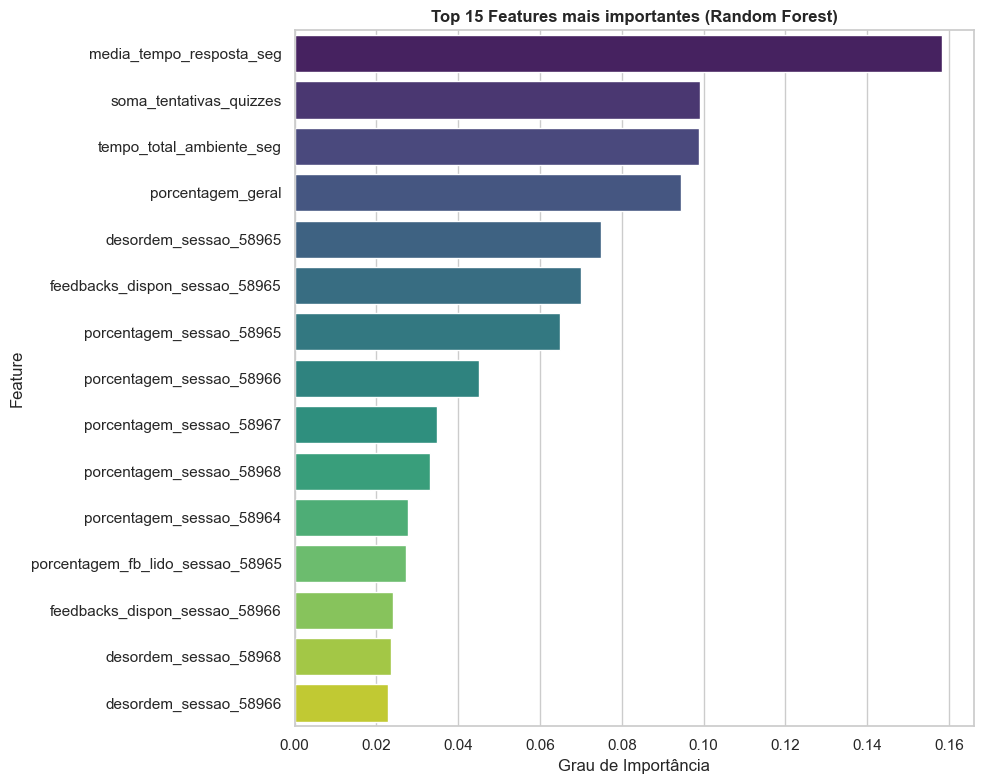

In [103]:
def plotar_importancia_features(modelo, X_train):
    """
    Extrai as importâncias das features do modelo treinado e plota um gráfico.
    """
    # Extrai as importâncias
    importancias = modelo.feature_importances_
    
    # Cria um DataFrame para facilitar a ordenação
    df_importancia = pd.DataFrame({
        'Feature': X_train.columns,
        'Importancia': importancias
    }).sort_values(by='Importancia', ascending=False)

    #df_importancia = df_importancia[df_importancia['Feature'].str.startswith('porcentagem_sessao_')]  #Pega apenas as features porcentagem_sessao_*

    # Plota
    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importancia', y='Feature', data=df_importancia.head(15), palette='viridis')
    plt.title('Top 15 Features mais importantes (Random Forest)', fontweight='bold')
    plt.xlabel('Grau de Importância')
    plt.tight_layout()
    plt.show()
    
    return df_importancia

# Exemplo de uso (chame logo após o .fit() do seu melhor Random Forest)
# melhor_modelo_rf = ... (seu objeto de modelo treinado)
df_imp = plotar_importancia_features(melhor_modelo, melhor_X)

### Hipótese 1: Existe uma correlação positiva e direta entre o tempo de engajamento ativo do estudante no Ambiente Virtual de Aprendizagem (AVA) e o seu desempenho acadêmico.

🔬 Testando a Hipótese 1...


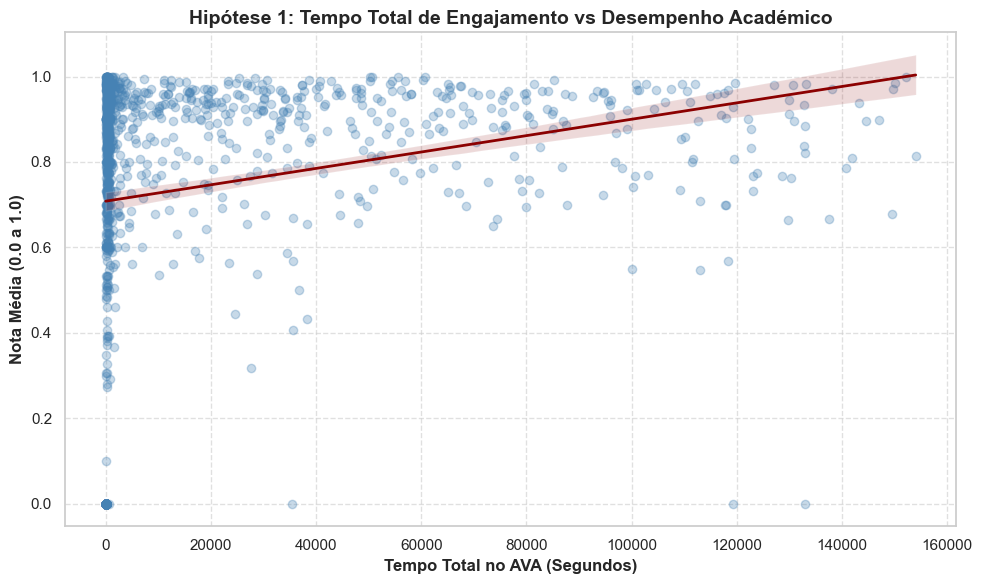

📊 Resultado Estatístico (Spearman):
   ↳ Coeficiente de Correlação (rho): 0.3429
   ↳ P-value: 5.0166e-38
   ✅ Conclusão: A Hipótese 1 é ACEITE. Existe correlação positiva e estatisticamente significativa.


In [104]:
# ==========================================
# TESTE DA HIPÓTESE 1: Tempo de Engajamento vs Desempenho
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
import numpy as np

print("🔬 Testando a Hipótese 1...")

# 1. Preparar a base unificada (Garantindo a penalidade dos evadidos com fillna 0.0)
df_hipoteses = pd.merge(df_final, df_target, on='username', how='left')
df_hipoteses['nota_media'] = df_hipoteses['nota_media'].fillna(0.0)

# 2. Remover outliers extremos de tempo apenas para a visualização gráfica ficar limpa
limite_tempo = df_hipoteses['media_tempo_resposta_seg'].quantile(0.95)
df_plot_h1 = df_hipoteses[df_hipoteses['media_tempo_resposta_seg'] <= limite_tempo]

# 3. Gráfico de Dispersão com Regressão
plt.figure(figsize=(10, 6))
sns.regplot(
    data=df_plot_h1, 
    x='media_tempo_resposta_seg', 
    y='nota_media', 
    scatter_kws={'alpha':0.3, 'color': 'steelblue'}, 
    line_kws={'color':'darkred', 'linewidth': 2}
)

plt.title('Hipótese 1: Tempo Total de Engajamento vs Desempenho Académico', fontweight='bold', fontsize=14)
plt.xlabel('Tempo Total no AVA (Segundos)', fontweight='bold')
plt.ylabel('Nota Média (0.0 a 1.0)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Prova Estatística (Spearman)
corr_h1, p_value_h1 = spearmanr(df_hipoteses['media_tempo_resposta_seg'], df_hipoteses['nota_media'], nan_policy='omit')
print(f"📊 Resultado Estatístico (Spearman):")
print(f"   ↳ Coeficiente de Correlação (rho): {corr_h1:.4f}")
print(f"   ↳ P-value: {p_value_h1:.4e}")

if p_value_h1 < 0.05:
    if corr_h1 > 0:
        print("   ✅ Conclusão: A Hipótese 1 é ACEITE. Existe correlação positiva e estatisticamente significativa.")
    else:
        print("   ❌ Conclusão: A Hipótese 1 é REJEITADA. A correlação é negativa.")
else:
    print("   ❌ Conclusão: A Hipótese 1 é REJEITADA. O resultado não tem significância estatística (p > 0.05).")

### Hipótese 2: O percentual de curso acessado por aluno apresenta a correlação positiva mais forte com o desempenho acadêmico final do aluno dentre todas as variáveis extraídas do ambiente virtual.

🔬 Testando a Hipótese 2...


C:\Users\Danilus04\AppData\Local\Temp\ipykernel_128840\3488018873.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


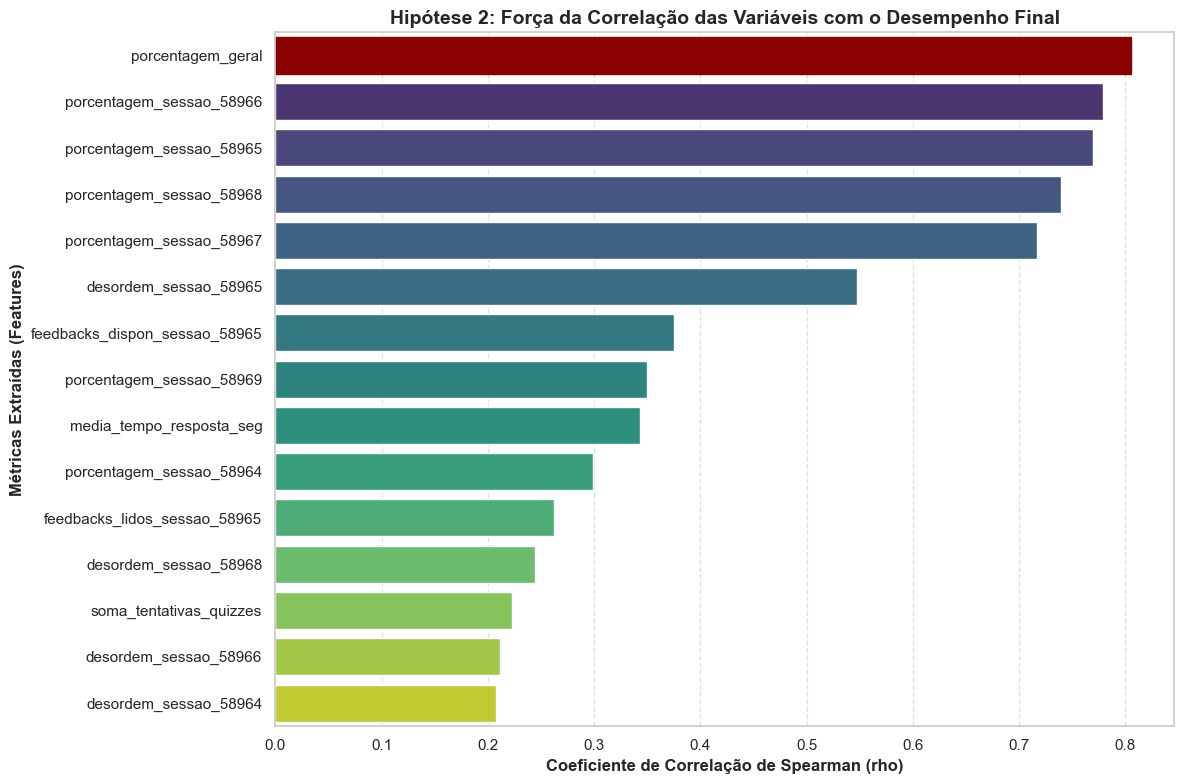

📊 Ranking das 5 Variáveis Mais Correlacionadas:


,nota_media
porcentagem_geral,0.805698
porcentagem_sessao_58966,0.778930
porcentagem_sessao_58965,0.769399
porcentagem_sessao_58968,0.739636
porcentagem_sessao_58967,0.716683


   ✅ Conclusão: A Hipótese 2 é ACEITE. A 'porcentagem_geral' obteve o maior coeficiente (0.8057).


In [105]:
# TESTE DA HIPÓTESE 2: O Poder Preditivo da Porcentagem Geral

print("🔬 Testando a Hipótese 2...")

# 1. Calcular a correlação de Spearman de todas as variáveis em relação à nota média
# Ignoramos variáveis não numéricas e a própria nota
matriz_corr = df_hipoteses.select_dtypes(include=[np.number]).corr(method='spearman')
correlacoes_com_alvo = matriz_corr['nota_media'].drop('nota_media').sort_values(ascending=False)

# 2. Preparar os dados dos Top 15 preditores para o gráfico
df_corr_plot = correlacoes_com_alvo.head(15).reset_index()
df_corr_plot.columns = ['Variável', 'Correlação (Spearman)']

# 3. Gráfico de Barras Horizontal
plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=df_corr_plot, 
    x='Correlação (Spearman)', 
    y='Variável', 
    palette='viridis'
)

# Destacar a barra da 'porcentagem_geral' se ela existir no top 15
for p, item in zip(ax.patches, df_corr_plot['Variável']):
    if item == 'porcentagem_geral':
        p.set_color('darkred') # Pinta a barra da hipótese 2 de vermelho para destaque

plt.title('Hipótese 2: Força da Correlação das Variáveis com o Desempenho Final', fontweight='bold', fontsize=14)
plt.xlabel('Coeficiente de Correlação de Spearman (rho)', fontweight='bold')
plt.ylabel('Métricas Extraídas (Features)', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Prova Estatística e Verificação da Hipótese
melhor_variavel = correlacoes_com_alvo.index[0]
maior_correlacao = correlacoes_com_alvo.iloc[0]

print(f"📊 Ranking das 5 Variáveis Mais Correlacionadas:")
display(correlacoes_com_alvo.head(5).to_frame())

if melhor_variavel == 'porcentagem_geral':
    print(f"   ✅ Conclusão: A Hipótese 2 é ACEITE. A 'porcentagem_geral' obteve o maior coeficiente ({maior_correlacao:.4f}).")
else:
    print(f"   ❌ Conclusão: A Hipótese 2 é REJEITADA. A métrica com maior correlação foi '{melhor_variavel}' ({maior_correlacao:.4f}).")